# Statistics on graphs

In [1]:
import networkx
import torch, torch_geometric
import numpy as np
import scipy
import matplotlib.pyplot as plt
import time

import pyvista as pv
import os

import karstnet as kn

# import json
import pickle

In [2]:
# Choose backend for matplotlib
# -----------------------------
from IPython import get_ipython
# get_ipython().run_line_magic('matplotlib', 'widget')
get_ipython().run_line_magic('matplotlib', 'inline')

# Or simply:
# %matplotlib widget
# %matplotlib inline

In [3]:
# Choose backend for pyvista with jupyter
# ---------------------------------------
# pv.set_jupyter_backend('trame')  # 3D-interactive plots
pv.set_jupyter_backend('static') # static plots

# Notes:
# -> ignored if run in a standard python shell
# -> use keyword argument "notebook=False" in Plotter() to open figure in a pop-up window

## Load local functions 

In [4]:
print('Load local functions...')

# import sys
# sys.path.insert(1, '../utils/')

# from graph_utils import *
# # from graph_rnn import *
# from graph_ddpm import *
# # from ml_utils import *
# from general_utils import *
# from graph_plot import *
# # from magic_utils import *
 
with open('../utils/graph_utils.py') as f: exec(f.read())
# with open('../utils/graph_rnn.py') as f: exec(f.read())
with open('../utils/graph_ddpm.py') as f: exec(f.read())
# with open('../utils/ml_utils.py') as f: exec(f.read())
with open('../utils/general_utils.py') as f: exec(f.read())
with open('../utils/graph_plot.py') as f: exec(f.read())
# with open('../utils/magic_utils.py') as f: exec(f.read())

Load local functions...


<string>:826: SyntaxWarning: invalid escape sequence '\m'
<string>:854: SyntaxWarning: invalid escape sequence '\m'
<string>:92: SyntaxWarning: invalid escape sequence '\s'


## Load parameters

Some parameters (dimension / attribute considered and indexes / parameters for plotting graphs)


In [5]:
print('Load parameters...')

# from params import *

with open('params.py') as f: exec(f.read())

Load parameters...


## Output settings

In [6]:
print('Define output settings...')

# Output directory (for saving)
# -----------------------------
fig_dir = 'fig'      # PARAMS

plt_show = True      # PARAMS (show graphics 2D ?)
off_screen = False   # PARAMS (show graphics 3D ?)

save_fig_png = True  # PARAMS
fig_prefix = '07'    # PARAMS

fig_counter = 0

if not os.path.isdir(fig_dir):
    os.mkdir(fig_dir)


Define output settings...


## Load graphs

### Load graphs from data set

In [7]:
print('Load graphs from data set...')

# Load from pickle file
data_dir = 'data_gen'
filename_graph_collection_data_set = os.path.join(data_dir, f'graph_collection_data_set.pickle')

with open(filename_graph_collection_data_set, 'rb') as f: data_set_G_list = pickle.load(f)

Load graphs from data set...


In [8]:
# print('Load graphs from data set...')

# # Alternative - read from text files (provides the same lists)
# # ============================================================

# data_dir = 'data_gen'
# filename_base = 'graph_collection_data_set'

# if attr is not None:
#     node_attrs      = ['pos', attr]
#     node_attrs_ind  = [tuple(range(dim)), [dim + i for i in range(attr_ncomp)]]
#     node_attrs_type = ['float', 'float']
# else:
#     node_attrs      = ['pos']
#     node_attrs_ind  = [tuple(range(dim))]
#     node_attrs_type = ['float']

# # Load graph list for data set
# data_set_G_list_2 = load_networkx_graph_list(
#     data_dir, filename_base, 
#     suffix_nodes='_nodes.dat', 
#     suffix_edges='_links.dat', 
#     delimiter_nodes=' ',  
#     delimiter_edges=' ',
#     node_attrs=node_attrs,
#     node_attrs_ind=node_attrs_ind,
#     nodet_attrs_type=node_attrs_type,
#     start_id_at_0=True)

# # Check
# # -----
# ok_list = []
# for i, (G1, G2) in enumerate(zip(data_set_G_list, data_set_G_list_2)):
#     ok = True
#     # print(f'graph #{i} ...')
#     check_list = compare_graph(G1, G2, node_attrs, verbose=0)
#     # print(f'graph #{i:3d} - check_list = {check_list}')
#     ok_list.append(np.all(check_list))

# print(f'`data_set_G_list` and `data_set_G_list_2` are equal ? {np.all(ok_list)}')
# # print(ok_list)

In [9]:
# print('Load graphs from data set...')

# # Alternative - read from ddpm data set (generated in notebook 03_graphDDPM_model_train.ipynb) and transform 
# # (provides the same lists)
# # ===========================================================================================================

# in_dir_ddpm = 'out_graphDDPM_model'
# # filename_hyper_param_ddpm_net = os.path.join(in_dir_ddpm, 'ddpm_net_hyper_params.txt')
# # filename_hyper_param_ddpm     = os.path.join(in_dir_ddpm, 'ddpm_hyper_params.txt')
# # filename_param_ddpm     = os.path.join(in_dir_ddpm, 'ddpm.params')
# filename_data_set_ddpm_shift = os.path.join(in_dir_ddpm, f'data_set_shift.txt')
# filename_data_set_ddpm_scale_factor = os.path.join(in_dir_ddpm, f'data_set_scale_factor.txt')
# filename_data_set_ddpm = os.path.join(in_dir_ddpm, f'data_set.pickle')

# # Load data set
# with open(filename_data_set_ddpm, 'rb') as f: data_set = pickle.load(f)

# # Load node features shift and scale factor
# with open(filename_data_set_ddpm_shift, 'r') as f: node_features_shift = np.loadtxt(f)
# with open(filename_data_set_ddpm_scale_factor, 'r') as f: node_features_scale_factor = np.loadtxt(f)

# node_features_shift_inv = - node_features_shift
# node_features_scale_factor_inv = 1.0 / node_features_scale_factor

# n_node_features = len(node_features_scale_factor)

# # Get data_set_G_list
# data_set_G_list_2 = []
# for G_geom in data_set.G_geom_list:
#     # G_geom.x = torch.from_numpy(node_features_scale_factor_inv).to(torch.float)*G_geom.x
#     G = torch_geometric.utils.to_networkx(G_geom, to_undirected=True, node_attrs=['x'])
#     G = multiply_graph_node_features(G, 'x', node_features_scale_factor_inv, inplace=True)
#     G = shift_graph_node_features(G, 'x', node_features_shift_inv, inplace=True)

#     v = np.asarray(list(networkx.get_node_attributes(G, 'x').values()))
#     remove_node_attribute(G, 'x')

#     dict_pos = {i:vi[:dim].tolist() for i, vi in enumerate(v)}
#     networkx.set_node_attributes(G, dict_pos, 'pos')

#     if attr is not None:
#         dict_attr = {i:vi[dim:].tolist() for i, vi in enumerate(v)}
#         networkx.set_node_attributes(G, dict_attr, attr)
#     else:
#         dict_attr = None

#     data_set_G_list_2.append(G)

# # Check
# # -----
# if attr is not None:
#     node_attrs      = ['pos', attr]
# else:
#     node_attrs      = ['pos']
    
# ok_list = []
# for i, (G1, G2) in enumerate(zip(data_set_G_list, data_set_G_list_2)):
#     ok = True
#     # print(f'graph #{i} ...')
#     check_list = compare_graph(G1, G2, node_attrs, verbose=0, atol=1e-07)
#     # print(f'graph #{i:3d} - check_list = {check_list}')
#     ok_list.append(np.all(check_list))

# print(f'`data_set_G_list` and `data_set_G_list_2` are equal ? {np.all(ok_list)}')
# # print(ok_list)

### Load list of generated graphs

In [10]:
print('Load generated graphs...')

in_dir_gen = 'out_gen_graph' 
filename_gen_graph_pk = os.path.join(in_dir_gen, f'gen_graph_list.pickle')

# Load list of generated graph (G_gen_list: of generated graphs in networkx format)
with open(filename_gen_graph_pk, 'rb') as f: G_gen_list = pickle.load(f)


Load generated graphs...


In [11]:
# print('Load generated graphs...')

# # Alternative - read from text files (provides the same lists)
# # ============================================================

# in_dir_gen = 'out_gen_graph' 
# filename_gen_graph_basename_txt = 'gen_graph_list'

# if attr is not None:
#     node_attrs      = ['pos', attr]
#     node_attrs_ind  = [tuple(range(dim)), [dim + i for i in range(attr_ncomp)]]
#     node_attrs_type = ['float', 'float']
# else:
#     node_attrs      = ['pos']
#     node_attrs_ind  = [tuple(range(dim))]
#     node_attrs_type = ['float']

# G_gen_list_2 = load_networkx_graph_list(
#     in_dir_gen, 
#     filename_gen_graph_basename_txt,
#     suffix_nodes='_nodes.dat', 
#     suffix_edges='_links.dat', 
#     delimiter_nodes=' ',  
#     delimiter_edges=' ',
#     node_attrs=node_attrs,
#     node_attrs_ind=node_attrs_ind,
#     nodet_attrs_type=node_attrs_type,
#     start_id_at_0=True)

# # Check
# # -----
# ok_list = []
# for i, (G1, G2) in enumerate(zip(G_gen_list, G_gen_list_2)):
#     ok = True
#     # print(f'graph #{i} ...')
#     check_list = compare_graph(G1, G2, node_attrs, verbose=0)
#     # print(f'graph #{i:3d} - check_list = {check_list}')
#     ok_list.append(np.all(check_list))
#     break

# print(f'`G_gen_list` and `G_gen_list_2` are equal ? {np.all(ok_list)}')
# # print(ok_list)

## Post-processing

In [137]:
from scipy.spatial import cKDTree

# ============================================================
# 1. MAIN WORKFLOW
# ============================================================

def postprocess_graph_topology(G, distance_factor=0.5):
    """
    Full topology-preserving postprocessing:
    - merges close nodes (instead of deleting)
    - preserves connectivity
    - adds edge intersections
    """

    if len(G.nodes()) == 0:
        return G.copy()

    # --- positions ---
    pos = networkx.get_node_attributes(G, 'pos')
    nodes = list(G.nodes())
    coords = np.array([pos[n] for n in nodes])

    # --- nearest neighbor distances ---
    tree = cKDTree(coords)
    dists, _ = tree.query(coords, k=2)
    nn_dist = dists[:, 1]

    mean_nn = np.mean(nn_dist)
    threshold = distance_factor * mean_nn

    # --- cluster nodes ---
    clusters = cluster_nodes(coords, threshold)

    # --- merge clusters ---
    G_merged, pos_merged = merge_clusters(G, nodes, coords, clusters)

    # --- add intersections ---
    G_final = add_intersections_safe(G_merged, pos_merged)

    return G_final


# ============================================================
# 2. CLUSTER CLOSE NODES
# ============================================================

def cluster_nodes(coords, threshold):
    tree = cKDTree(coords)
    visited = np.zeros(len(coords), dtype=bool)
    clusters = []

    for i in range(len(coords)):
        if visited[i]:
            continue

        idx = tree.query_ball_point(coords[i], threshold)

        for j in idx:
            visited[j] = True

        clusters.append(idx)

    return clusters


# ============================================================
# 3. MERGE CLUSTERS (TOPOLOGY PRESERVED)
# ============================================================

def merge_clusters(G, nodes, coords, clusters):
    G_new = networkx.Graph()
    pos_new = {}
    node_map = {}

    assigned = set()

    for i, cluster in enumerate(clusters):
        cluster_nodes = [nodes[j] for j in cluster]

        # centroid of cluster
        centroid = coords[cluster].mean(axis=0)

        new_id = i
        G_new.add_node(new_id)
        pos_new[new_id] = tuple(centroid)

    for old_node in cluster_nodes:
        node_map[old_node] = new_id
        assigned.add(old_node)

    next_id = len(clusters)

    for node in nodes:
        if node not in assigned:
            G_new.add_node(next_id)
            pos_new[next_id] = tuple(coords[nodes.index(node)])
            node_map[node] = next_id
            next_id += 1

    # --- rewire edges ---
    for u, v in G.edges():
        if u not in node_map or v not in node_map:
            continue
        u_new = node_map[u]
        v_new = node_map[v]

        if u_new != v_new:
            G_new.add_edge(u_new, v_new)

    # remove duplicates & self-loops
    G_new.remove_edges_from(networkx.selfloop_edges(G_new))

    networkx.set_node_attributes(G_new, pos_new, 'pos')

    return G_new, pos_new


# ============================================================
# 4. ADD EDGE INTERSECTIONS (SAFE)
# ============================================================

def add_intersections_safe(G, pos):
    G_new = G.copy()
    edges = list(G.edges())

    next_node = max(G.nodes()) + 1 if len(G.nodes()) > 0 else 0

    for i, (u1, v1) in enumerate(edges):
        for u2, v2 in edges[i+1:]:

            # skip shared nodes
            if len({u1, v1, u2, v2}) < 4:
                continue

            p1, p2 = pos[u1], pos[v1]
            p3, p4 = pos[u2], pos[v2]

            inter = segment_intersection(p1, p2, p3, p4)

            if inter is None:
                continue

            # add node
            G_new.add_node(next_node, pos=inter)

            # split edges safely
            if G_new.has_edge(u1, v1):
                G_new.remove_edge(u1, v1)
                G_new.add_edge(u1, next_node)
                G_new.add_edge(next_node, v1)

            if G_new.has_edge(u2, v2):
                G_new.remove_edge(u2, v2)
                G_new.add_edge(u2, next_node)
                G_new.add_edge(next_node, v2)

            pos[next_node] = inter
            next_node += 1

    return G_new


# ============================================================
# 5. SEGMENT INTERSECTION
# ============================================================

def segment_intersection(p1, p2, p3, p4):
    def det(a, b):
        return a[0]*b[1] - a[1]*b[0]

    xdiff = (p1[0]-p2[0], p3[0]-p4[0])
    ydiff = (p1[1]-p2[1], p3[1]-p4[1])

    div = det(xdiff, ydiff)
    if abs(div) < 1e-10:
        return None # parallel

    d = (det(p1, p2), det(p3, p4))
    x = det(d, xdiff) / div
    y = det(d, ydiff) / div

    # bounding box check
    def within(a, b, c):
        return min(a, b) <= c <= max(a, b)

        if (within(p1[0], p2[0], x) and within(p1[1], p2[1], y) and
            within(p3[0], p4[0], x) and within(p3[1], p4[1], y)):
            return (x, y)

    return None


# ============================================================
# 6. APPLY TO LIST OF GRAPHS
# ============================================================

def postprocess_graph_list(G_list, distance_factor=0.5):
    return [postprocess_graph_topology(G, distance_factor) for G in G_list]


# ============================================================
# 7. OPTIONAL CLEANUP (REMOVE ISOLATED NODES)
# ============================================================

def remove_isolates(G):
    G = G.copy()
    G.remove_nodes_from(list(networkx.isolates(G)))
    return G


In [140]:
G_gen_list_pospro = postprocess_graph_list(G_gen_list, distance_factor=2)

### Set in "Karstnet format"

In [150]:
print('Set graphs of data set and generated graphs in "Karstnet format"...')

# Karstnet graph with attribute (properties)
if attr is not None:
    data_set_KG_list = [kn.KGraph(G.edges(), networkx.get_node_attributes(G, 'pos'), 
                                  properties=networkx.get_node_attributes(G, attr), verbose=False) for G in data_set_G_list]

    KG_gen_list = [kn.KGraph(G.edges(), networkx.get_node_attributes(G, 'pos'), 
                             properties=networkx.get_node_attributes(G, attr), verbose=False) for G in G_gen_list_pospro]
else:
    data_set_KG_list = [kn.KGraph(G.edges(), networkx.get_node_attributes(G, 'pos'), 
                                  verbose=False) for G in data_set_G_list]

    KG_gen_list = [kn.KGraph(G.edges(), networkx.get_node_attributes(G, 'pos'), 
                             verbose=False) for G in G_gen_list_pospro]

Set graphs of data set and generated graphs in "Karstnet format"...


## Show first graphs

### Graphs of data set

Plot first graphs of data set (2D)...


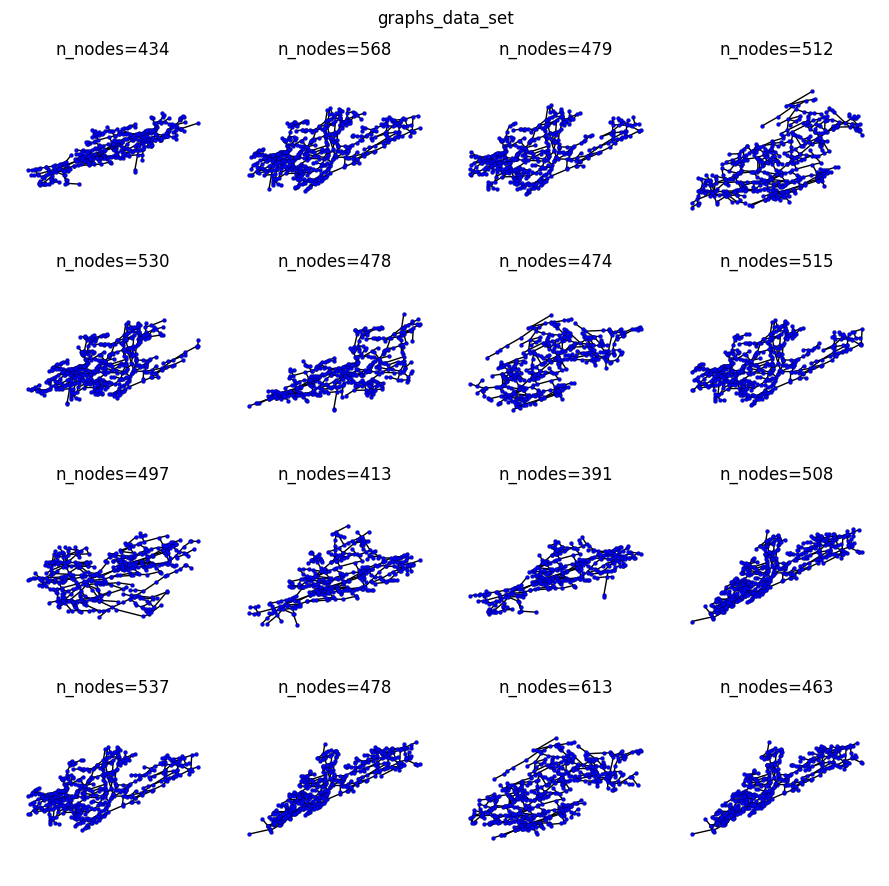

In [13]:
print('Plot first graphs of data set (2D)...')

G_list = data_set_G_list[:16]
out_name = 'graphs_data_set'

# 2D view
# =======
kwds = kwds_multi.copy()

figsize = figsize_multi
# -----

same_color_bar = False

plot_graph_multi_2d_from_G_networkx_list(
        G_list, 
        out_name=out_name, 
        nr=None,
        attr=attr,
        attr_label_list=attr_label_list, 
        attr_cmap_list=attr_cmap_list,
        title_list=None, title_fontsize=12,
        figsize=figsize, save_fig_png=save_fig_png, 
        filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
        with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
        show=plt_show,
        **kwds)

In [14]:
if save_fig_png:
    fig_counter = fig_counter+1

### Generated graphs (graphRNN + ddpm)

Plot first generated graphs (2D)...


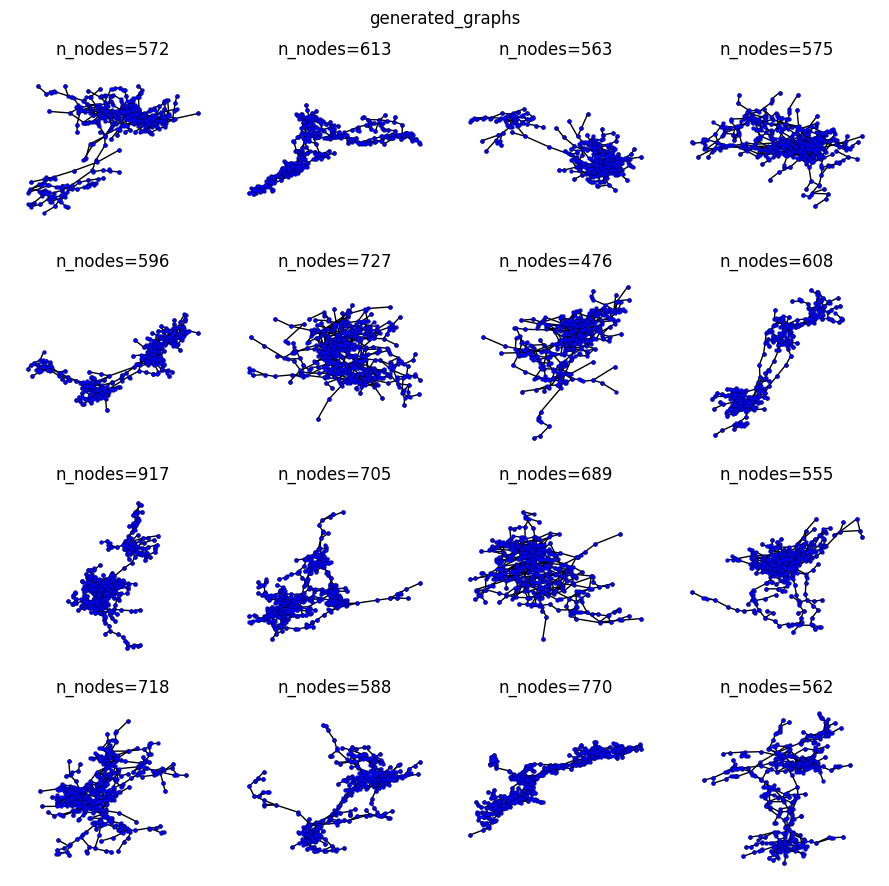

In [141]:
print('Plot first generated graphs (2D)...')

G_list = G_gen_list_pospro[:16]
out_name = 'generated_graphs'

# 2D view
# =======
kwds = kwds_multi.copy()

figsize = figsize_multi
# -----

same_color_bar = False

plot_graph_multi_2d_from_G_networkx_list(
        G_list, 
        out_name=out_name, 
        nr=None,
        attr=attr,
        attr_label_list=attr_label_list, 
        attr_cmap_list=attr_cmap_list,
        title_list=None, title_fontsize=12,
        figsize=figsize, save_fig_png=save_fig_png, 
        filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
        with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
        show=plt_show,
        **kwds)

In [16]:
if save_fig_png:
    fig_counter = fig_counter+1

## Statistics

In [17]:
# Colors for further graphs
col_gen = 'blue'
col_data = 'tab:orange'

col2_gen = 'darkblue'
col2_data = 'tab:red'


### Number of nodes

Compute and plot statistics - number of nodes...


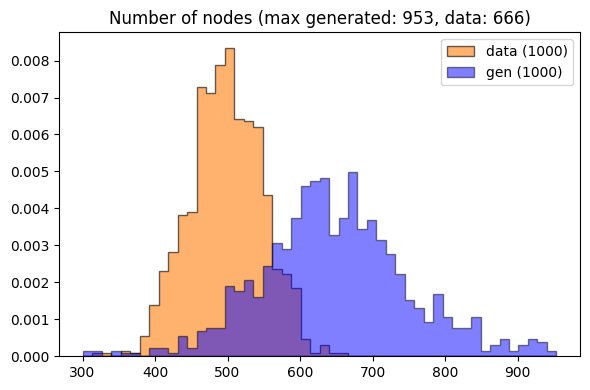

In [142]:
print('Compute and plot statistics - number of nodes...')

#figsize = figsize_lh3
figsize = (6,4)

# Histogram of number of nodes
data_n_nodes = np.asarray([G.number_of_nodes() for G in data_set_G_list])
gen_n_nodes  = np.asarray([G.number_of_nodes() for G in G_gen_list_pospro])

# Plot
vmin = min(data_n_nodes.min(), gen_n_nodes.min()) - 0.5
vmax = max(data_n_nodes.max(), gen_n_nodes.max()) + 0.5
nb = min(int(vmax - vmin), 50)
bins = np.linspace(vmin, vmax, nb+1)

plt.figure(figsize=figsize)
plt.hist(data_n_nodes, density=True, bins=bins, color=col_data, alpha=.6, histtype='stepfilled', edgecolor='black', label=f'data ({len(data_n_nodes)})')
plt.hist(gen_n_nodes,  density=True, bins=bins, color=col_gen,  alpha=.5, histtype='stepfilled', edgecolor='black', label=f'gen ({len(gen_n_nodes)})')
plt.legend()
plt.title(f'Number of nodes (max generated: {gen_n_nodes.max()}, data: {data_n_nodes.max()})')
#plt.grid()

if save_fig_png:
    plt.tight_layout()
    plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_stats_nb_nodes_pos.png')
    fig_counter = fig_counter+1

if plt_show:
    plt.show()
else:
    plt.close()

Plot histogram of node features...


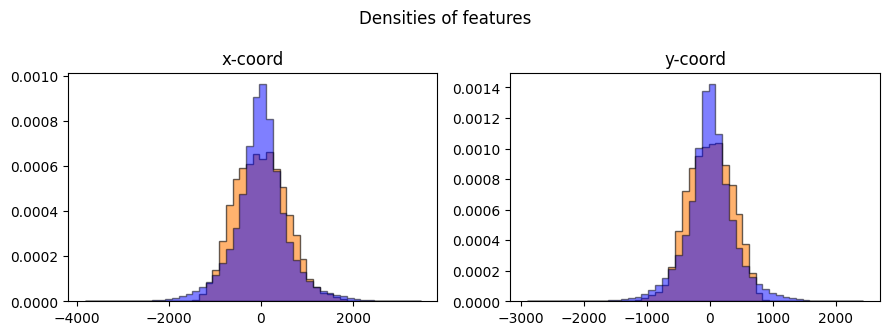

In [143]:
print('Plot histogram of node features...')

# Histogram of each node feature (coordinates of postion and attributes)
# ======================================================================
if dim==2:
    leg = ['x-coord', 'y-coord']
    col = ['tab:blue', 'tab:orange']
else:
    leg = ['x-coord', 'y-coord', 'z-coord']
    col = ['tab:blue', 'tab:orange', 'tab:purple']

if attr is not None:
    leg = leg + attr_label_list
    col = col + attr_ncomp*['tab:green']

ng = len(leg)
nr = int(np.sqrt(ng))
nc = ng//nr + (ng%nr>0)

figsize = (figsize_lh3[0], figsize_lh3[1]*nr*.75)

data_x_features = np.vstack([list(networkx.get_node_attributes(G, 'pos').values()) for G in data_set_G_list])
if attr is not None:
    v = np.vstack([list(networkx.get_node_attributes(G, attr).values()) for G in data_set_G_list])
    data_x_features = np.hstack((data_x_features, v))

gen_x_features = np.vstack([list(networkx.get_node_attributes(G, 'pos').values()) for G in G_gen_list_pospro])
if attr is not None:
    v = np.vstack([list(networkx.get_node_attributes(G, attr).values()) for G in G_gen_list_pospro])
    gen_x_features = np.hstack((gen_x_features, v))

x_features_min = np.vstack((data_x_features.min(axis=0), gen_x_features.min(axis=0))).min(axis=0)
x_features_max = np.vstack((data_x_features.max(axis=0), gen_x_features.max(axis=0))).max(axis=0)
x_features_nb = len(leg)*[50]
x_features_bins = [np.linspace(a, b, nb+1) for a, b, nb in zip(x_features_min, x_features_max, x_features_nb)]

# Plot
# ----
plt.subplots(nr, nc, figsize=figsize)
for i, label in enumerate(leg):
    plt.subplot(nr, nc, i+1)
    plt.hist(data_x_features[:, i], density=True, bins=x_features_bins[i], color=col_data, alpha=.6, histtype='stepfilled', edgecolor='black', label=f'data')
    plt.hist(gen_x_features[:, i],  density=True, bins=x_features_bins[i], color=col_gen,  alpha=.5,  histtype='stepfilled', edgecolor='black', label=f'gen')
    plt.title(f'{label}')
    #plt.legend()

for i in range(ng, nr*nc):
    plt.subplot(nr, nc, i+1)
    plt.axis('off')

plt.suptitle(f'Densities of features')

if save_fig_png:
    plt.tight_layout()
    plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_stats_node_features_pospro.png', transparent=True)
    # fig_counter = fig_counter+1

if plt_show:
    plt.show()
else:
    plt.close()

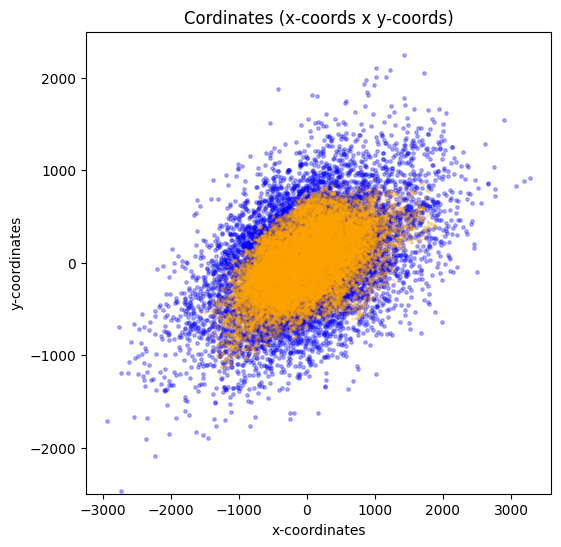

In [144]:
# Coordinates cross-plot
x_data = data_x_features[:,0]
y_data = data_x_features[:,1]

x_gen = gen_x_features[:,0]
y_gen = gen_x_features[:,1]

plt.figure(figsize=(6,6))

n = 20000
idx_data = np.random.choice(len(x_data), n, replace=False)
idx_gen = np.random.choice(len(x_gen), n, replace=False)
plt.scatter(x_gen[idx_gen], y_gen[idx_gen], edgecolor='blue', color='blue', s=6, alpha=.3, label='gen')
plt.scatter(x_data[idx_data], y_data[idx_data], edgecolor='none', color='orange', s=6, alpha=.3, label='data')
plt.ylim(-2500, 2500)

plt.xlabel('x-coordinates')
plt.ylabel('y-coordinates')
#plt.legend()
#plt.axis('equal')
plt.title('Cordinates (x-coords x y-coords)')

plt.savefig('Crossplot_coord_pospro.jpg', dpi=300)
plt.show()

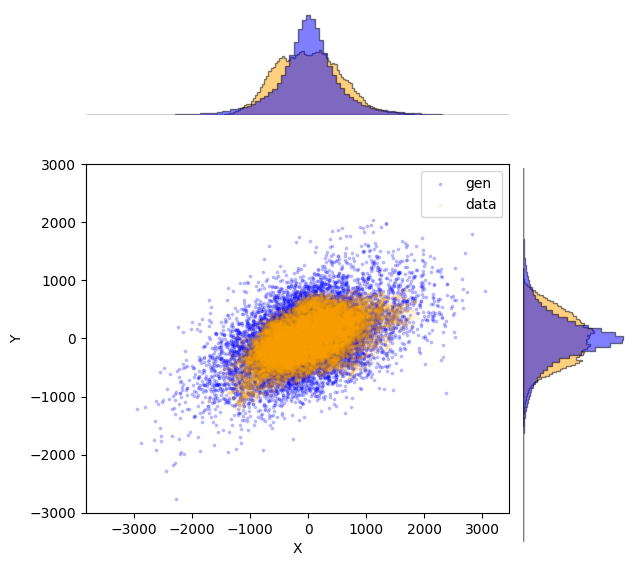

In [103]:
# Coordinates
x_data = data_x_features[:, 0]
y_data = data_x_features[:, 1]

x_gen = gen_x_features[:, 0]
y_gen = gen_x_features[:, 1]

# Subsample
n = 20000
idx_data = np.random.choice(len(x_data), n, replace=False)
idx_gen = np.random.choice(len(x_gen), n, replace=False)

x_data_s, y_data_s = x_data[idx_data], y_data[idx_data]
x_gen_s, y_gen_s = x_gen[idx_gen], y_gen[idx_gen]

# --- Layout ---
fig = plt.figure(figsize=(7,7))
gs = fig.add_gridspec(2, 2, 
width_ratios=(4,1), 
height_ratios=(1,4),
wspace=0.05, hspace=0.05)

ax_scatter = fig.add_subplot(gs[1,0])
ax_histx = fig.add_subplot(gs[0,0], sharex=ax_scatter)
ax_histy = fig.add_subplot(gs[1,1], sharey=ax_scatter)

# --- Scatter ---
ax_scatter.scatter(x_gen_s, y_gen_s, s=3, alpha=0.2, color='blue', label='gen')
ax_scatter.scatter(x_data_s, y_data_s, s=3, alpha=0.1, color='orange', label='data')


ax_scatter.set_xlabel("X")
ax_scatter.set_ylabel("Y")
ax_scatter.set_aspect('equal')

ax_scatter.set_ylim(-3000, 3000)
xmin = min(x_data.min(), x_gen.min())
xmax = max(x_data.max(), x_gen.max())
ax_scatter.set_xlim(xmin, xmax)

ax_scatter.legend()

# --- Top histogram (X) ---
bins = 100

ax_histx.hist(x_data, bins=bins, density=True, alpha=0.5, histtype='stepfilled', edgecolor='black', color='orange')
ax_histx.hist(x_gen, bins=bins, density=True, alpha=0.5, histtype='stepfilled', edgecolor='black', color='blue')

ax_histx.tick_params(axis="x", bottom=False, labelbottom=False)
ax_histx.tick_params(axis="y", left=False, labelleft=False)
ax_histx.set_frame_on(False)

# --- Right histogram (Y) ---
ax_histy.hist(y_data, bins=bins, density=True, alpha=0.5, color='orange', histtype='stepfilled', edgecolor='black', orientation='horizontal')
ax_histy.hist(y_gen, bins=bins, density=True, alpha=0.5, color='blue', histtype='stepfilled', edgecolor='black', orientation='horizontal')

ax_histy.tick_params(axis="x", bottom=False, labelbottom=False)
ax_histy.tick_params(axis="y", left=False, labelleft=False)
ax_histy.set_frame_on(False)


plt.show()


In [21]:
# %%skip_if attr_ncomp < 2
if attr_ncomp >= 2:
    print('Cross-plot of node features...')

    # Cross plot of pair of attributes
    # ================================

    figsize = figsize_equal_def

    data_attr = np.vstack([list(networkx.get_node_attributes(G, attr).values()) for G in data_set_G_list])
    gen_attr  = np.vstack([list(networkx.get_node_attributes(G, attr).values()) for G in G_gen_list])

    for i_attr in range(attr_ncomp):
        # loop on attributes
        attr_label_i = attr_label_list[i_attr]
        
        for j_attr in range(i_attr+1, attr_ncomp):
            # loop on attributes
            attr_label_j = attr_label_list[j_attr]

            plt.figure(figsize=figsize)
            plt.scatter(data_attr[:, i_attr], data_attr[:, j_attr], c=col_data, alpha=.1, s=20, marker='o', label='data')
            plt.scatter(gen_attr [:, i_attr], gen_attr [:, j_attr], c=col_gen,  alpha=.1, s=20, marker='o', label='gen')
            plt.xlabel(f'{attr_label_i}')
            plt.ylabel(f'{attr_label_j}')
            plt.grid()
            plt.legend()

            plt.title(f'Cross plot attributes {i_attr} vs {j_attr}')

            if save_fig_png:
                plt.tight_layout()
                plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_stats_cross_plot_{attr}_{i_attr}_{j_attr}.png')
                # fig_counter = fig_counter+1

            if plt_show:
                plt.show()
            else:
                plt.close()

In [22]:
if save_fig_png:
    fig_counter = fig_counter+1


## Statistics on nodes
Compute some statistics on nodes of every graph in data set and in generated list (and set results as node attributes).
The statistics measures computed are: *length, azimuth, degree, betweenness_centrality, estrada_index, average_clustering, global_efficiency*.

Below, $n$ denotes the number of nodes in the graph, $u$, $v$ are nodes of the graph, $d(v)$ is the degree of $v$, and $d(u,v)$ is the length of the shortest path between node $u$ and $v$ (in number of edges).

- $degree\_centrality(v) = d(v)/(n-1)$ 
- $betweenness\_centrality(v) = \frac{2}{(n-1)(n-2)}\sum_{\{s, t\} : s \neq t, s\neq v\neq t} \frac{\vert\{shortest\ path\ btw\ s\ and\ t\ going\ through\ v\}\vert}{\vert\{shortest\ path\ btw\ s\ and\ t\}\vert}$
- estrada_index
- average_clustering
- global_eficiency

Functions for length and azimuth below.

In [146]:
import math
# Calculate lengths from graph edges
def lengths(graph):
    pos = networkx.get_node_attributes(graph, 'pos')

    for u, v in graph.edges():
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        
        length = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
        graph[u][v]['length'] = round(length, 3)

In [147]:
def normalize_graph_lengths(G, method='mean'):
    lengths = networkx.get_edge_attributes(G, 'length')
    if not lengths:
        return G # skip if no lengths

    # Save original lengths
    networkx.set_node_attributes(G, lengths, 'original_length')

    # Choose norm factor
    if method == 'max':
        norm_factor = max(lengths.values())
    elif method == 'area':
        pos = networkx.get_node_attributes(G, 'pos')
        xs = [p[0] for p in pos.values()]
        ys = [p[1] for p in pos.values()]
        area = (max(xs) - min(xs)) * (max(ys) - min(ys))
        norm_factor = np.sqrt(area) if area > 0 else 1.0
    else: # default is 'mean'
        norm_factor = np.mean(list(lengths.values()))

    # Avoid division by zero
    norm_factor = norm_factor if norm_factor > 0 else 1.0

    # Apply normalization
    normalized = {edge: l / norm_factor for edge, l in lengths.items()}
    networkx.set_edge_attributes(G, normalized, 'norm_length')

    # Store factor for possible reversal
    G.graph['length_norm_factor'] = norm_factor
    G.graph['length_norm_method'] = method

In [148]:
# Calculate azimuths from graph edges
def azimuths(graph):
    pos = networkx.get_node_attributes(graph, 'pos')
    for u, v in graph.edges():
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        
        # Calculate the angle between the edge and the positive y-axis
        angle_radians = math.atan2(x2 - x1, y2 - y1)
        graph[u][v]['rad'] = round(angle_radians, 2)
        
        angle_degrees = math.degrees(angle_radians)
        azimuth = (angle_degrees + 360) % 360
        graph[u][v]['azimuth'] = round(azimuth, 2) 

### Computation
Comments and loads the files if already existing (see next section).

In [26]:
print('Compute statistics on graph nodes (topology)...')

Compute statistics on graph nodes (topology)...


In [27]:
# Graphs in data set
t1 = time.time()
for G in data_set_G_list:
    networkx.set_node_attributes(G, dict(networkx.degree(G)), 'degree')
    networkx.set_node_attributes(G, networkx.betweenness_centrality(G), 'betweenness_centrality')
    networkx.set_node_attributes(G, networkx.estrada_index(G), 'estrada_index')
    networkx.set_node_attributes(G, networkx.average_clustering(G), 'av_clustering')
    #networkx.set_node_attributes(G, networkx.global_efficiency(G), 'global')
    azimuths(G)
    lengths(G)
    normalize_graph_lengths(G)
t2 = time.time()
print(f'Elapsed time for computing statistics on nodes ({len(data_set_G_list)} graph(s)): {t2-t1:.3g} s')

Elapsed time for computing statistics on nodes (1000 graph(s)): 648 s


In [149]:
# Generated graphs
t1 = time.time()
for G in G_gen_list_pospro:
    networkx.set_node_attributes(G, dict(networkx.degree(G)), 'degree')
    networkx.set_node_attributes(G, networkx.betweenness_centrality(G), 'betweenness_centrality')
    networkx.set_node_attributes(G, networkx.estrada_index(G), 'estrada_index')
    networkx.set_node_attributes(G, networkx.average_clustering(G), 'av_clustering')
    #networkx.set_node_attributes(G, networkx.global_efficiency(G), 'global')
    azimuths(G)
    lengths(G)
    normalize_graph_lengths(G)
t2 = time.time()
print(f'Elapsed time for computing statistics on nodes ({len(G_gen_list)} graph(s)): {t2-t1:.3g} s')

Elapsed time for computing statistics on nodes (1000 graph(s)): 578 s


### Save to / Load from file (pickle)
Comments appropriate lines.

In [29]:
# Graphs in data set with stats on nodes
filename_data_set_graph_stats_pk = os.path.join(in_dir_gen, f'data_set_graph_list_with_stats_on_nodes.pickle')

# Save pickle
print('Save data set with statistics on nodes (topology)...')
with open(filename_data_set_graph_stats_pk, 'wb') as f: pickle.dump(data_set_G_list, file=f)

# # Load pickle
# print('Load data set with statistics on nodes (topology)...')
# with open(filename_data_set_graph_stats_pk, 'rb') as f: data_set_G_list = pickle.load(f)

Save data set with statistics on nodes (topology)...


In [30]:
# Generated graphs with stats on nodes
filename_gen_graph_stats_pk = os.path.join(in_dir_gen, f'gen_graph_list_with_stats_on_nodes.pickle')

# Save pickle
print('Save generated graphs with statistics on nodes (topology)...')
with open(filename_gen_graph_stats_pk, 'wb') as f: pickle.dump(G_gen_list, file=f)

# # Load pickle
# print('Load generated graphs with statistics on nodes (topology)...')
# with open(filename_gen_graph_stats_pk, 'rb') as f: G_gen_list = pickle.load(f)

Save generated graphs with statistics on nodes (topology)...


### Plots

In [31]:
print('Plot statistics on graph nodes (topology)...')

Plot statistics on graph nodes (topology)...


In [32]:
figsize = (12,3)

### Length

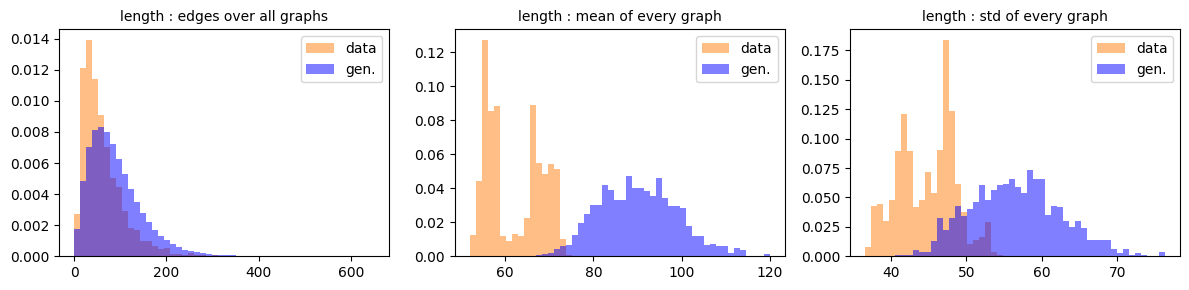

In [33]:
# Attribute (key)
attr_stat = 'length'

# Set distribution
# ----------------
# distribution of each graph
data_distrib = [np.array(list(networkx.get_edge_attributes(G, attr_stat).values())) for G in data_set_G_list]
gen_distrib  = [np.array(list(networkx.get_edge_attributes(G, attr_stat).values())) for G in G_gen_list]
# Note: each entry in the lists above is an array of values of length equal to the number of edges in the corresponding graph

# distribution of all graphs together
data_distrib_all = np.hstack(data_distrib)
gen_distrib_all  = np.hstack(gen_distrib)

# distribution of mean for each graph
data_distrib_mean = np.asarray([d.mean() for d in data_distrib])
gen_distrib_mean  = np.asarray([d.mean() for d in gen_distrib])

# distribution of standard deviation for each graph
data_distrib_std = np.asarray([d.std() for d in data_distrib])
gen_distrib_std  = np.asarray([d.std() for d in gen_distrib])

# Plot
# ----
plt.subplots(1,3, figsize=figsize)

plt.subplot(1,3,1)
vmin = min(data_distrib_all.min(), gen_distrib_all.min()) - 0.01
vmax = max(data_distrib_all.max(), gen_distrib_all.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_all, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_all,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : edges over all graphs', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,2)
vmin = min(data_distrib_mean.min(), gen_distrib_mean.min()) - 0.01
vmax = max(data_distrib_mean.max(), gen_distrib_mean.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_mean, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_mean,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : mean of every graph', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,3)
vmin = min(data_distrib_std.min(), gen_distrib_std.min()) - 0.01
vmax = max(data_distrib_std.max(), gen_distrib_std.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_std, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_std,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : std of every graph', fontsize=10)
plt.legend()
#plt.grid()

if save_fig_png:
    plt.tight_layout()
    plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_stats_{attr_stat}_1.png')
    # fig_counter = fig_counter+1

if plt_show:
    plt.show()
else:
    plt.close()

### Azimuth

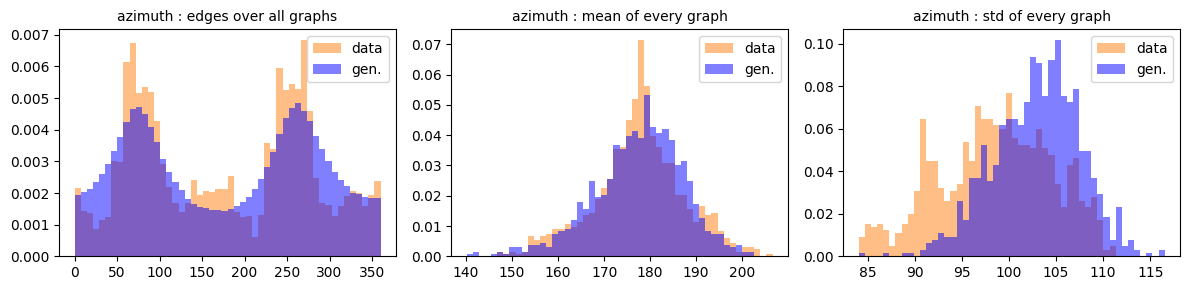

In [34]:
# Attribute (key)
attr_stat = 'azimuth'

# Set distribution
# ----------------
# distribution of each graph
data_distrib = [np.array(list(networkx.get_edge_attributes(G, attr_stat).values())) for G in data_set_G_list]
gen_distrib  = [np.array(list(networkx.get_edge_attributes(G, attr_stat).values())) for G in G_gen_list]
# Note: each entry in the lists above is an array of values of length equal to the number of edges in the corresponding graph

# distribution of all graphs together
data_distrib_all = np.hstack(data_distrib)
gen_distrib_all  = np.hstack(gen_distrib)

# distribution of mean for each graph
data_distrib_mean = np.asarray([d.mean() for d in data_distrib])
gen_distrib_mean  = np.asarray([d.mean() for d in gen_distrib])

# distribution of standard deviation for each graph
data_distrib_std = np.asarray([d.std() for d in data_distrib])
gen_distrib_std  = np.asarray([d.std() for d in gen_distrib])

# Plot
# ----
plt.subplots(1,3, figsize=figsize)

plt.subplot(1,3,1)
vmin = min(data_distrib_all.min(), gen_distrib_all.min()) - 0.01
vmax = max(data_distrib_all.max(), gen_distrib_all.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_all, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_all,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : edges over all graphs', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,2)
vmin = min(data_distrib_mean.min(), gen_distrib_mean.min()) - 0.01
vmax = max(data_distrib_mean.max(), gen_distrib_mean.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_mean, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_mean,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : mean of every graph', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,3)
vmin = min(data_distrib_std.min(), gen_distrib_std.min()) - 0.01
vmax = max(data_distrib_std.max(), gen_distrib_std.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_std, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_std,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : std of every graph', fontsize=10)
plt.legend()
#plt.grid()

if save_fig_png:
    plt.tight_layout()
    plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_stats_{attr_stat}_1.png')
    # fig_counter = fig_counter+1

if plt_show:
    plt.show()
else:
    plt.close()

In [35]:
import math

def simplify(graph, threshold):
    graph = graph.copy()
    pos = networkx.get_node_attributes(graph, 'pos')

    changed = True

    while changed:
        changed = False

        for node in list(graph.nodes()):
            if graph.degree(node) == 2:
                n1, n2 = list(graph.neighbors(node))

                if graph.has_edge(n1,node) and graph.has_edge(node, n2):
                    l1 = graph[n1][node].get('length', None)
                    l2 = graph[node][n2].get('length', None)

                    if l1 is None or l2 is None:
                        continue

                    if l1 < threshold and l2 < threshold:
                        graph.add_edge(n1, n2)
                        graph.remove_node(node)

                        changed = True
                        break
    return graph 

In [36]:
lengths = networkx.get_edge_attributes(G, 'length')
threshold = 0.01*sum(lengths.values())/len(lengths)

In [37]:
clean_graphs = []

for G in G_gen_list:
    G2 = simplify(G, threshold)
    clean_graphs.append(G2)

### Degree

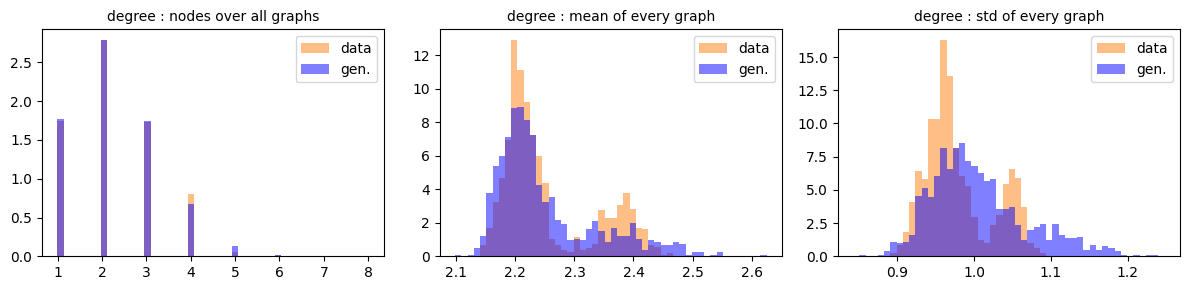

In [38]:
# Attribute (key)
attr_stat = 'degree'

# Set distribution
# ----------------
# distribution of each graph
data_distrib = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in data_set_G_list]
gen_distrib  = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in G_gen_list]
# Note: each entry in the lists above is an array of values of length equal to the number of nodes in the corresponding graph

# distribution of all graphs together
data_distrib_all = np.hstack(data_distrib)
gen_distrib_all  = np.hstack(gen_distrib)

# distribution of mean for each graph
data_distrib_mean = np.asarray([d.mean() for d in data_distrib])
gen_distrib_mean  = np.asarray([d.mean() for d in gen_distrib])

# distribution of standard deviation for each graph
data_distrib_std = np.asarray([d.std() for d in data_distrib])
gen_distrib_std  = np.asarray([d.std() for d in gen_distrib])

# Plot
# ----
plt.subplots(1,3, figsize=figsize)

plt.subplot(1,3,1)
vmin = min(data_distrib_all.min(), gen_distrib_all.min()) - 0.01
vmax = max(data_distrib_all.max(), gen_distrib_all.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_all, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_all,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : nodes over all graphs', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,2)
vmin = min(data_distrib_mean.min(), gen_distrib_mean.min()) - 0.01
vmax = max(data_distrib_mean.max(), gen_distrib_mean.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_mean, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_mean,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : mean of every graph', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,3)
vmin = min(data_distrib_std.min(), gen_distrib_std.min()) - 0.01
vmax = max(data_distrib_std.max(), gen_distrib_std.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_std, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_std,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : std of every graph', fontsize=10)
plt.legend()
#plt.grid()

if save_fig_png:
    plt.tight_layout()
    plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_stats_{attr_stat}_1.png')
    # fig_counter = fig_counter+1

if plt_show:
    plt.show()
else:
    plt.close()

### Betweenness centrality

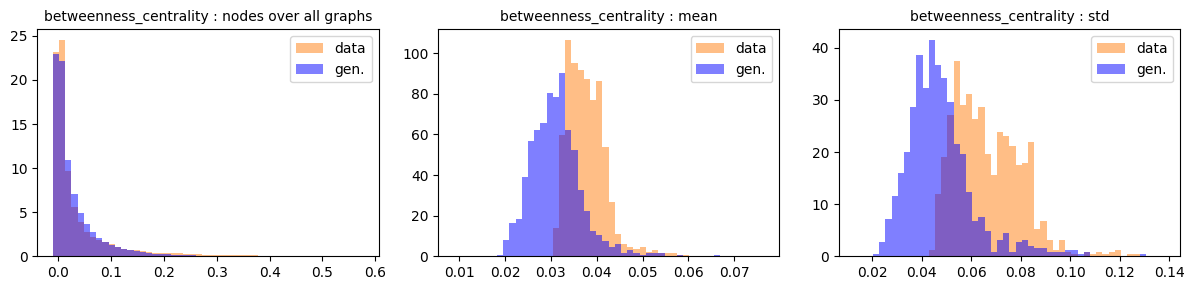

In [39]:
# Attribute (key)
attr_stat = 'betweenness_centrality'

# Set distribution
# ----------------
# distribution of each graph
data_distrib = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in data_set_G_list]
gen_distrib  = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in G_gen_list]
# Note: each entry in the lists above is an array of values of length equal to the number of nodes in the corresponding graph

# distribution of all graphs together
data_distrib_all = np.hstack(data_distrib)
gen_distrib_all  = np.hstack(gen_distrib)

# distribution of mean for each graph
data_distrib_mean = np.asarray([d.mean() for d in data_distrib])
gen_distrib_mean  = np.asarray([d.mean() for d in gen_distrib])

# distribution of standard deviation for each graph
data_distrib_std = np.asarray([d.std() for d in data_distrib])
gen_distrib_std  = np.asarray([d.std() for d in gen_distrib])

# Plot
# ----
plt.subplots(1,3, figsize=figsize)

plt.subplot(1,3,1)
vmin = min(data_distrib_all.min(), gen_distrib_all.min()) - 0.01
vmax = max(data_distrib_all.max(), gen_distrib_all.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_all, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_all,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : nodes over all graphs', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,2)
vmin = min(data_distrib_mean.min(), gen_distrib_mean.min()) - 0.01
vmax = max(data_distrib_mean.max(), gen_distrib_mean.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_mean, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_mean,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : mean', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,3)
vmin = min(data_distrib_std.min(), gen_distrib_std.min()) - 0.01
vmax = max(data_distrib_std.max(), gen_distrib_std.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_std, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_std,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : std', fontsize=10)
plt.legend()
#plt.grid()

if save_fig_png:
    plt.tight_layout()
    plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_stats_{attr_stat}_1.png')
    # fig_counter = fig_counter+1

if plt_show:
    plt.show()
else:
    plt.close()

### Estrada Index

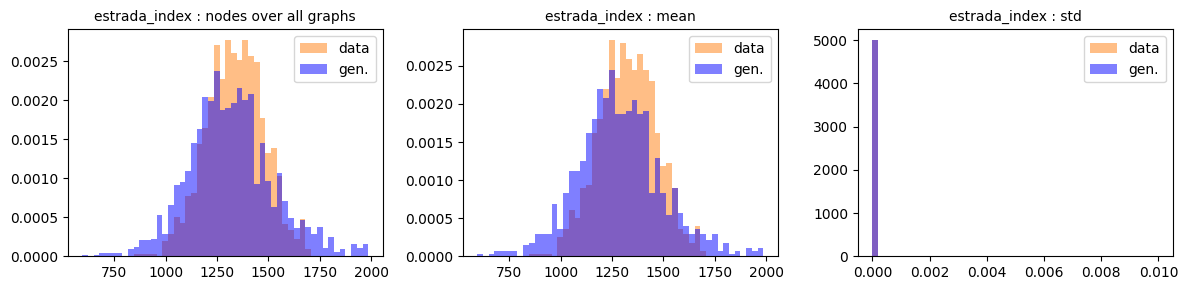

In [40]:
# Attribute (key)
attr_stat = 'estrada_index'

# Set distribution
# ----------------
# distribution of each graph
data_distrib = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in data_set_G_list]
gen_distrib  = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in G_gen_list]
# Note: each entry in the lists above is an array of values of length equal to the number of nodes in the corresponding graph

# distribution of all graphs together
data_distrib_all = np.hstack(data_distrib)
gen_distrib_all  = np.hstack(gen_distrib)

# distribution of mean for each graph
data_distrib_mean = np.asarray([d.mean() for d in data_distrib])
gen_distrib_mean  = np.asarray([d.mean() for d in gen_distrib])

# distribution of standard deviation for each graph
data_distrib_std = np.asarray([d.std() for d in data_distrib])
gen_distrib_std  = np.asarray([d.std() for d in gen_distrib])


# Plot
# ----
plt.subplots(1,3, figsize=figsize)

plt.subplot(1,3,1)
vmin = min(data_distrib_all.min(), gen_distrib_all.min()) 
vmax = max(data_distrib_all.max(), gen_distrib_all.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_all, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_all,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : nodes over all graphs', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,2)
vmin = min(data_distrib_mean.min(), gen_distrib_mean.min()) 
vmax = max(data_distrib_mean.max(), gen_distrib_mean.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_mean, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_mean,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : mean', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,3)
vmin = min(data_distrib_std.min(), gen_distrib_std.min()) 
vmax = max(data_distrib_std.max(), gen_distrib_std.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_std, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_std,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : std', fontsize=10)
plt.legend()
#plt.grid()

if save_fig_png:
    plt.tight_layout()
    plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_stats_{attr_stat}_1.png')
    # fig_counter = fig_counter+1

if plt_show:
    plt.show()
else:
    plt.close()

## Karstnet statistics (global on graph)

The class `KGraph` has methods to compute statistics (float numbers), and the method `characterize_graph` compute those statistics and store them in a dictionary, as given in the table below.

The statistics marked with (*) in the description below are computed on the simplified graph, which consists of the graph obtained by removing the nodes of degree 2. A branch of a graph is path where all the nodes except the two extremities are nodes of degree 2.

| method                    | key                        | description |
|:------                    |:-----                      |:------------|
|`coef_variation_length`    |'cv length'                 | coefficient of variation (std. dev. / mean) of branch length                 |
|`length_entropy`           |'length entropy'            | entropy of branch length                                                     |
|                           |'cv degree'                 | coefficient of variation of node degrees (*)                                 |
|`correlation_vertex_degree`|'correlation vertex degree' | correlation of node degrees over pairs of connected nodes (assortativity) (*)|

In [41]:
print('Compute Karstnet statistics...')

Compute Karstnet statistics...


In [42]:
# Karstnet statistics for data set
t1 = time.time()
data_corr_node_degree    = np.asarray([KG.correlation_vertex_degree() for KG in data_set_KG_list])
data_mean_degree, data_CV_degree = np.asarray([KG.mean_degree_and_CV() for KG in data_set_KG_list]).T
t2 = time.time()
print(f'Elapsed time for computing statistics (global) ({len(data_set_KG_list)} graph(s)): {t2-t1:.3g} s')

Elapsed time for computing statistics (global) (1000 graph(s)): 3.58 s


In [151]:
# Karstnet statistics for generated graphs
t1 = time.time()
gen_corr_node_degree    = np.asarray([KG.correlation_vertex_degree() for KG in KG_gen_list])
gen_mean_degree, gen_CV_degree = np.asarray([KG.mean_degree_and_CV() for KG in KG_gen_list]).T
t2 = time.time()
print(f'Elapsed time for computing statistics (global) ({len(KG_gen_list)} graph(s)): {t2-t1:.3g} s')

Elapsed time for computing statistics (global) (1000 graph(s)): 3.46 s


In [44]:
if save_fig_png:
    fig_counter = fig_counter+1


### Graphics - histograms

In [152]:
figsize=(8,8)

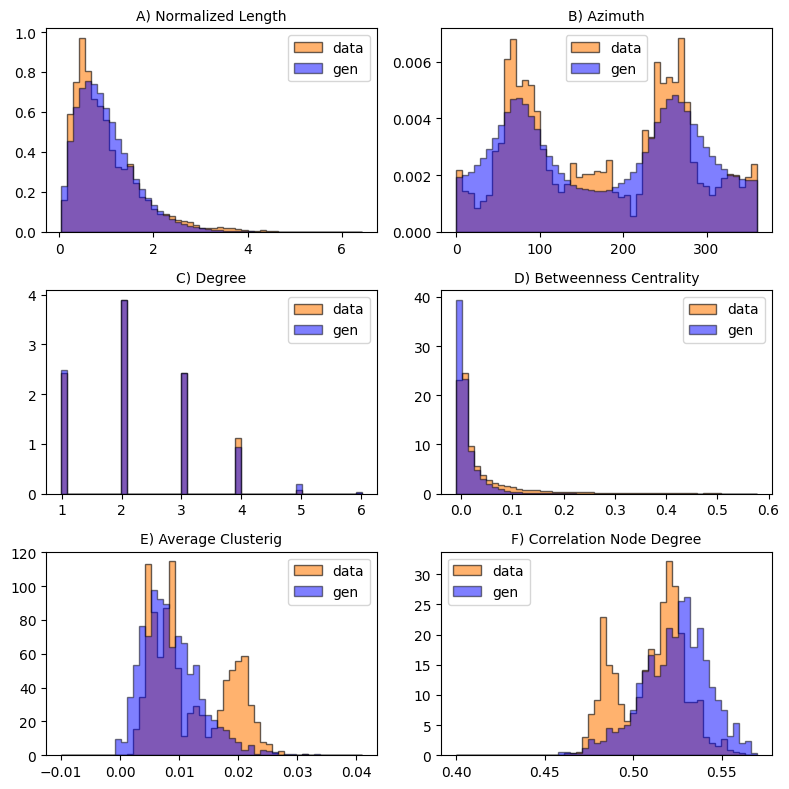

In [153]:
# Set distributions to plot
# ----------------
# distribution of each graph
data_distrib_len = [np.array(list(networkx.get_edge_attributes(G, 'norm_length').values())) for G in data_set_G_list]
gen_distrib_len  = [np.array(list(networkx.get_edge_attributes(G, 'norm_length').values())) for G in G_gen_list_pospro]
# Note: each entry in the lists above is an array of values of length equal to the number of edges in the corresponding graph

# distribution of standard deviation for each graph
data_distrib_std_len = np.asarray([d.std() for d in data_distrib_len])
gen_distrib_std_len  = np.asarray([d.std() for d in gen_distrib_len])

data_distrib_len_all = np.hstack(data_distrib_len)
gen_distrib_len_all  = np.hstack(gen_distrib_len)


data_distrib_az = [np.array(list(networkx.get_edge_attributes(G, 'azimuth').values())) for G in data_set_G_list]
gen_distrib_az  = [np.array(list(networkx.get_edge_attributes(G, 'azimuth').values())) for G in G_gen_list_pospro]

data_distrib_std_az = np.asarray([d.std() for d in data_distrib_az])
gen_distrib_std_az  = np.asarray([d.std() for d in gen_distrib_az])

data_distrib_az_all = np.hstack(data_distrib_az)
gen_distrib_az_all  = np.hstack(gen_distrib_az)


data_distrib_deg = [np.array(list(networkx.get_node_attributes(G, 'degree').values())) for G in data_set_G_list]
gen_distrib_deg  = [np.array(list(networkx.get_node_attributes(G, 'degree').values())) for G in G_gen_list_pospro]

data_distrib_deg_all = np.hstack(data_distrib_deg)
gen_distrib_deg_all  = np.hstack(gen_distrib_deg)

data_distrib_std_deg = np.asarray([d.std() for d in data_distrib_deg])
gen_distrib_std_deg  = np.asarray([d.std() for d in gen_distrib_deg])


data_distrib_bc = [np.array(list(networkx.get_node_attributes(G, 'betweenness_centrality').values())) for G in data_set_G_list]
gen_distrib_bc  = [np.array(list(networkx.get_node_attributes(G, 'betweenness_centrality').values())) for G in G_gen_list_pospro]

data_distrib_bc_all = np.hstack(data_distrib_bc)
gen_distrib_bc_all  = np.hstack(gen_distrib_bc)

data_distrib_std_bc = np.asarray([d.std() for d in data_distrib_bc])
gen_distrib_std_bc  = np.asarray([d.std() for d in gen_distrib_bc])


data_distrib_ei = [np.array(list(networkx.get_node_attributes(G, 'estrada_index').values())) for G in data_set_G_list]
gen_distrib_ei  = [np.array(list(networkx.get_node_attributes(G, 'estrada_index').values())) for G in G_gen_list_pospro]

data_distrib_std_ei = np.asarray([d.std() for d in data_distrib_ei])
gen_distrib_std_ei  = np.asarray([d.std() for d in gen_distrib_ei])

data_distrib_ei_all = np.hstack(data_distrib_ei)
gen_distrib_ei_all  = np.hstack(gen_distrib_ei)

#data_x = data_corr_node_degree
#gen_x  = gen_corr_node_degree
#data_x, gen_x = data_x[~np.isnan(data_x)], gen_x[~np.isnan(gen_x)]

data_distrib_ac = [np.array(list(networkx.get_node_attributes(G, 'av_clustering').values())) for G in data_set_G_list]
gen_distrib_ac  = [np.array(list(networkx.get_node_attributes(G, 'av_clustering').values())) for G in G_gen_list_pospro]

data_distrib_std_ac = np.asarray([d.std() for d in data_distrib_ac])
gen_distrib_std_ac  = np.asarray([d.std() for d in gen_distrib_ac])

data_distrib_ac_all = np.hstack(data_distrib_ac)
gen_distrib_ac_all  = np.hstack(gen_distrib_ac)

# Plot
# ----
plt.subplots(3,2, figsize=figsize)

plt.subplot(3,2,1)
vmin = min(data_distrib_len_all.min(), gen_distrib_std_len.min()) - 0.01
vmax = max(data_distrib_len_all.max(), gen_distrib_std_len.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_len_all, density=True, bins=bins, color=col_data, alpha=.6, histtype='stepfilled', edgecolor='black', label='data')
plt.hist(gen_distrib_len_all,  density=True, bins=bins, color=col_gen, alpha=.5, histtype='stepfilled', edgecolor='black', label='gen')
plt.title('A) Normalized Length', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(3,2,2)
vmin = min(data_distrib_az_all.min(), gen_distrib_std_az.min()) - 0.01
vmax = max(data_distrib_az_all.max(), gen_distrib_std_az.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_az_all, density=True, bins=bins, color=col_data, alpha=.6, histtype='stepfilled', edgecolor='black', label='data')
plt.hist(gen_distrib_az_all,  density=True, bins=bins, color=col_gen, alpha=.5, histtype='stepfilled', edgecolor='black', label='gen')
plt.title('B) Azimuth', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(3,2,3)
vmin = min(data_distrib_deg_all.min(), gen_distrib_std_deg.min()) - 0.01
vmax = max(data_distrib_deg_all.max(), gen_distrib_std_deg.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_deg_all, density=True, bins=bins, color=col_data, alpha=.6, histtype='stepfilled', edgecolor='black', label='data')
plt.hist(gen_distrib_deg_all,  density=True, bins=bins, color=col_gen, alpha=.5, histtype='stepfilled', edgecolor='black', label='gen')
plt.title('C) Degree', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(3,2,4)
vmin = min(data_distrib_bc_all.min(), gen_distrib_std_bc.min()) - 0.01
vmax = max(data_distrib_bc_all.max(), gen_distrib_std_bc.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_bc_all, density=True, bins=bins, color=col_data, alpha=.6, histtype='stepfilled', edgecolor='black', label='data')
plt.hist(gen_distrib_bc_all,  density=True, bins=bins, color=col_gen, alpha=.5, histtype='stepfilled', edgecolor='black', label='gen')
plt.title('D) Betweenness Centrality', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(3,2,5)
vmin = min(data_distrib_ac_all.min(), gen_distrib_std_ac.min()) - 0.01
vmax = max(data_distrib_ac_all.max(), gen_distrib_std_ac.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_ac_all, density=True, bins=bins, color=col_data, alpha=.6, histtype='stepfilled', edgecolor='black', label=f'data')
plt.hist(gen_distrib_ac_all,  density=True, bins=bins, color=col_gen, alpha=.5, histtype='stepfilled', edgecolor='black', label='gen')
plt.title('E) Average Clusterig', fontsize=10)
plt.legend()
#plt.grid()

#vmin = min(data_distrib_ei_all.min(), gen_distrib_std_ei.min()) - 0.01
#vmax = max(data_distrib_ei_all.max(), gen_distrib_std_ei.max()) + 0.01
#nb = 50
#bins = np.linspace(vmin, vmax, nb+1)
#plt.hist(data_distrib_ei_all, density=True, bins=bins, color=col_data, alpha=.6, label=f'data')
#plt.hist(gen_distrib_ei_all,  density=True, bins=bins, color=col_gen, alpha=.5, histtype='stepfilled', edgecolor='black', label=f'gen')
#plt.title('E) Estrada Index', fontsize=10)
#plt.legend()
#plt.grid()

plt.subplot(3,2,6)
vmin = 0.4
vmax = max(data_x.max(), gen_distrib_std.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_x, density=True, bins=bins, color=col_data, alpha=.6, histtype='stepfilled', edgecolor='black', label='data')
plt.hist(gen_x,  density=True, bins=bins, color=col_gen,  alpha=.5, histtype='stepfilled', edgecolor='black', label='gen')
plt.title('F) Correlation Node Degree', fontsize=10)
plt.legend()
#plt.grid()

if save_fig_png:
    plt.tight_layout()
    plt.savefig('stats.png')
    # fig_counter = fig_counter+1

if plt_show:
    plt.show()
else:
    plt.close()